In [60]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import StandardScaler
np.set_printoptions(precision=2, suppress=True)
import math

In [5]:
pressure = np.array([8.63, 8.06, 2.42, 2.25, 8.19, 10.39, 3.22, 3.40, 8.88, 6.18, 5.57, 4.84, 1.70, 6.00, 4.32, 5.28, 6.94, 8.52, 7.87, 9.17, 1.20, 8.20, 6.96, 10.36, 11.33, 1.14, 10.11, 3.79, 7.87, 9.41, 10.32, 11.35, 7.98, 10.45, 6.47, 3.57, 2.76, 6.48, 9.20, 5.94, 8.49, 2.38])
flow = np.array([58.4, 31.1, 50.5, 45.1, 47.9, 26.1, 11.1, 30.0, 23.2, 26.9, 59.6, 22.0, 48.0, 14.1, 37.7, 24.1, 18.3, 26.6, 56.4, 36.8, 33.5, 49.2, 32.7, 11.2, 12.2, 44.5, 30.7, 16.5, 58.2, 19.9, 48.1, 22.4, 46.0, 34.0, 7.0, 44.2, 21.1, 28.9, 44.3, 59.7, 29.6, 42.0])
y_train = np.array([85.87, 42.93, 32.08, 24.51, 66.54, 45.93, 9.56, 19.77, 38.02, 30.59, 65.98, 19.79, 25.57, 18.03, 30.28, 23.58, 23.90, 38.53, 76.66, 54.95, 12.18, 69.04, 39.10, 24.54, 30.63, 18.50, 51.95, 12.85, 79.67, 34.81, 80.39, 44.62, 61.35, 57.08, 12.69, 35.08, 12.55, 35.13, 68.05, 67.93, 42.56, 24.42])

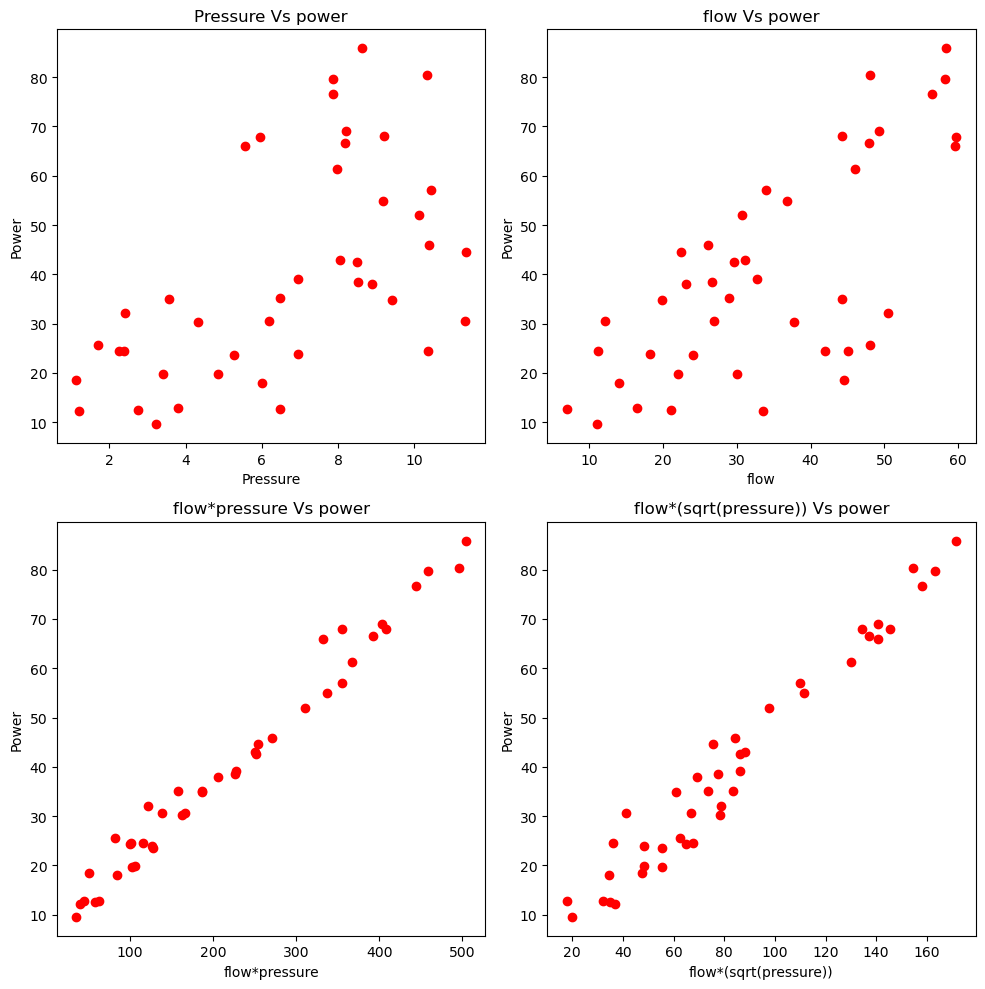

In [70]:
fig, ax = plt.subplots(2,2, figsize=(10, 10))

ax[0, 0].scatter(pressure, y_train, marker="o", color="r")
ax[0, 0].set_title("Pressure Vs power")
ax[0, 0].set_xlabel("Pressure")
ax[0, 0].set_ylabel("Power")

ax[0, 1].scatter(flow, y_train, marker="o", color="r")
ax[0, 1].set_title("flow Vs power")
ax[0, 1].set_xlabel("flow")
ax[0, 1].set_ylabel("Power")

ax[1, 0].scatter(flow*pressure, y_train, marker="o", color="r")
ax[1, 0].set_title("flow*pressure Vs power")
ax[1, 0].set_xlabel("flow*pressure")
ax[1, 0].set_ylabel("Power")

ax[1, 1].scatter((flow)*(np.sqrt(pressure)), y_train, marker="o", color="r")
ax[1, 1].set_title("flow*(sqrt(pressure)) Vs power")
ax[1, 1].set_xlabel("flow*(sqrt(pressure))")
ax[1, 1].set_ylabel("Power")

plt.tight_layout()
plt.show()

In [48]:
x_train = np.array([pressure, flow, pressure*flow, flow*(np.sqrt(pressure))])
x_train = x_train.T

In [49]:
scaler = StandardScaler()

x_scaled = scaler.fit_transform(x_train)
np.ptp(x_scaled, axis = 0)

array([3.45, 3.59, 3.42, 3.66])

In [50]:
sgdr = SGDRegressor(max_iter=10000)

sgdr.fit(x_scaled, y_train)
print(f"iterations ran for: {sgdr.n_iter_}, total w changes: {sgdr.t_}")

print(f"w: {sgdr.coef_}, b: {sgdr.intercept_}")

iterations ran for: 86, total w changes: 3613.0
w: [4.77 4.58 7.99 7.54], b: [40.12]


In [51]:
final_prediction = sgdr.predict(x_scaled);

sgdr.score(x_scaled, y_train)

0.9944279947611017

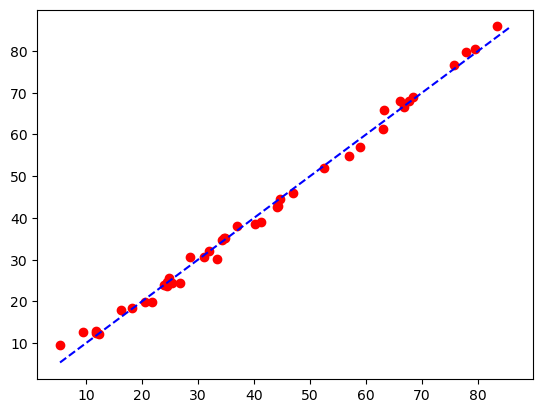

In [58]:
# prediction vs actual value plot
plt.scatter(final_prediction, y_train, marker = "o", color="r")

lo = min(min(final_prediction), min(y_train))
hi = max(max(final_prediction), max(y_train))

plt.plot([lo, hi], [lo, hi], color = "b", linestyle="--")

plt.show()

In [68]:
x = np.array([[7.0, 35.0, (7.0*35.0), (35.0*(math.sqrt(7)))]])
x_scale = scaler.transform(x)
final = sgdr.predict(x_scale)

print(f"Power for 7.0 bar of pressure and 35.0 L/min flow rate is {final[0]:.2f}")

Power for 7.0 bar of pressure and 35.0 L/min flow rate is 44.18
